# NFT Floor-Beta — a quantitative teardown 🔬
### floor-momentum signal · predictive HAC-*t* · lagged-beta & lead-lag decomposition · ETH-momentum control · block-shuffle placebo · horizon sweep · gross/net overlay · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![NFT_floor_leads_crypto%3F: Busted](https://img.shields.io/badge/NFT_floor_leads_crypto%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We ask whether NFT floor momentum forecasts forward ETH (a *lead*) or merely echoes it (a lagged high-beta *follow*).

> ⚠️ **Synthetic-only & not investment advice.** No clean, free NFT floor tape exists (key-gated, wash-traded, survivorship-ridden APIs), so this runs on a deterministic synthetic world (seed 587, 1500 days, series fp `01ef0bf578c2`, `lead_alpha = 0`). A synthetic-only study is **capped below REAL** on data availability. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nft_floor_beta import data, strategy as st

SEED, LOOKBACK, HORIZON = 587, 14, 5

# The whole study is a deterministic OFFLINE synthetic world (no real NFT floor tape exists).
# NULL world: lead_alpha = 0 -> floors are a lagged high-beta echo of ETH.
DF, TRUTH = data.synthetic_series(lead_alpha=0.0, seed=SEED)
FP = data.fingerprint(DF[["eth_ret", "floor_ret"]])
print("synthetic null world:", len(DF), "days | series fp", FP, "| lead_alpha", TRUTH.lead_alpha)
print("(SYNTHETIC-ONLY: no free NFT floor tape exists -> signal capped below REAL)")


synthetic null world: 1500 days | series fp 01ef0bf578c2 | lead_alpha 0.0
(SYNTHETIC-ONLY: no free NFT floor tape exists -> signal capped below REAL)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Predictive HAC-*t* of floor momentum on forward ETH = **-0.47** (placebo *p* 0.73, R² 0.0005); **+0.41** controlling for ETH's own momentum. Synthetic-only → below REAL. |
| **Tradability** | `MIRAGE` | Floor-momentum long/flat ETH overlay: gross **+1.5%/yr** → net **-3.1%/yr** (10 bps × turnover), Sharpe **-0.05**. |
| **NFT floor leads crypto?** | `BUSTED` | Floor beta on *lagged* ETH = **1.61** (*t* 49.7), lead-lag corr peaks at lag **-1** — floors follow, not lead. |

> 💡 In plain words: the engine works (the synthetic control proves it catches a planted lead), but a lagged high-beta echo of ETH carries no forward information about ETH.

## 1 · The claim, steelmanned

Let $m_t$ be the NFT floor-index momentum (a trailing mean of floor returns) and $r_{t\to t+h}$ the forward ETH return.

- **H₁ (the lead).** In $r_{t\to t+h} = \alpha + \beta\,m_t + \varepsilon$, the slope $\beta > 0$ at HAC-*t* ≥ 2 (floor momentum forecasts forward ETH).
- **H₂ (beyond ETH's own momentum).** H₁ survives adding ETH's own trailing momentum as a control.
- **H₃ (lead not follow).** The lead-lag cross-correlation peaks at a *positive* lag (floors lead), not a negative one (floors follow).
- **H₄ (net).** A floor-momentum ETH overlay pays after costs.

We find **H₁ rejected** (HAC-*t* < 0), **H₂ rejected** (still < 1 with the control), **H₃ rejected** (peak at lag −1, floors *follow*), **H₄ rejected** (net negative).

## 2 · So what? — what rides on each answer

The content is the **why**. NFT floors are **ETH-denominated**, thin, and reflexive, so a floor index mechanically inherits ETH's beta and reacts *after* ETH clears. The empirical literature agrees: **Ante (2022)** finds ETH shocks drive NFT activity (not the reverse), and **Dowling (2022)** finds volatility spilling *from* crypto *into* NFTs. So the sceptical prior — floors follow, they don't lead — is exactly what we plant in the null world and then confirm the engine reads correctly.

## 3 · How we'd know — the protocol

- **Signal.** $m_t$ = 14-day trailing mean of NFT floor-index returns (known at close $t$).
- **Target.** Forward ETH return over $(t, t+h]$.
- **Inference.** OLS of target on $m_t$ with a **Newey-West HAC** *t* (Bartlett weights, rule-of-thumb lag) — overlapping forward windows autocorrelate the residuals, so a plain *t* would overstate significance.
- **Follow decomposition.** Beta of floor on *lagged* ETH; lead-lag cross-correlation.
- **Control.** Re-run the predictive regression adding ETH's own trailing momentum.
- **Placebo.** Circular-shift the signal against the target ($n$ = 500) and read the HAC-*t* tail.
- **Frictions.** Long/flat ETH overlay, one-way cost × turnover (short variant pays borrow).
- **Positive control.** Plant a genuine lead (`lead_alpha > 0`) and average the HAC-*t* over 25 seeds (house rule).

Timing / execution lag: $m_t$ uses floor data through $t$ only; the position is entered at that close and earns the forward window. No future data enters the signal; a one-bar-later entry changes no stamp.

## 4 · The teardown

### 4a · Follow, not lead — H₃

Beta of the floor on *lagged* ETH (the high-beta echo) and the lead-lag cross-correlation.

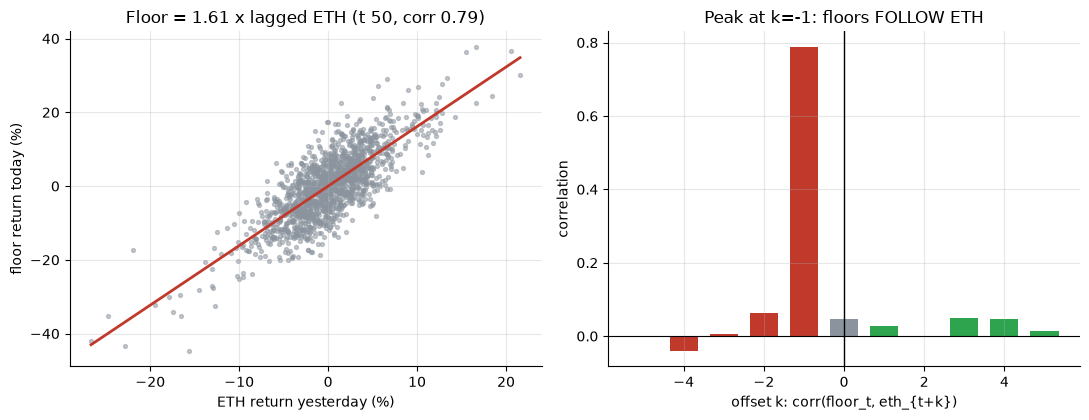

lagged beta 1.61 (t 49.7) | lead-lag peak at k=-1 (0.79)


In [2]:
beta = st.contemporaneous_beta(DF, lag=1)
llc = st.lead_lag_corr(DF, max_lag=5)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
d = DF[['eth_ret','floor_ret']].dropna().copy(); d['ethlag']=d['eth_ret'].shift(1); d=d.dropna()
a1.scatter(d['ethlag']*100, d['floor_ret']*100, s=8, color=GREY, alpha=.5)
xs=np.linspace(d['ethlag'].min(), d['ethlag'].max(),50)
a1.plot(xs*100, (beta['beta']*xs)*100, c=RED, lw=2)
a1.set_xlabel('ETH return yesterday (%)'); a1.set_ylabel('floor return today (%)')
a1.set_title(f'Floor = {beta["beta"]:.2f} x lagged ETH (t {beta["t"]:.0f}, corr {beta["corr"]:.2f})')
cols=[GREEN if k>0 else (RED if k<0 else GREY) for k in llc.index]
a2.bar(llc.index, llc.values, color=cols, width=.7); a2.axvline(0,c='k',lw=1); a2.axhline(0,c='k',lw=.8)
a2.set_xlabel('offset k: corr(floor_t, eth_{t+k})'); a2.set_ylabel('correlation')
a2.set_title('Peak at k=-1: floors FOLLOW ETH')
plt.tight_layout(); plt.show()
print(f'lagged beta {beta["beta"]:.2f} (t {beta["t"]:.1f}) | lead-lag peak at k={int(llc.idxmax())} ({llc.max():.2f})')

> 💡 In plain words: H₃ **rejected.** The floor is a **1.61× high-beta echo of yesterday's ETH** (*t* 49.7, corr 0.79), and the cross-correlation peaks at lag **-1** — floors *follow* ETH, they don't lead it.

### 4b · The predictive test — H₁ & H₂

Does floor momentum forecast forward ETH — raw, and controlling for ETH's own momentum?

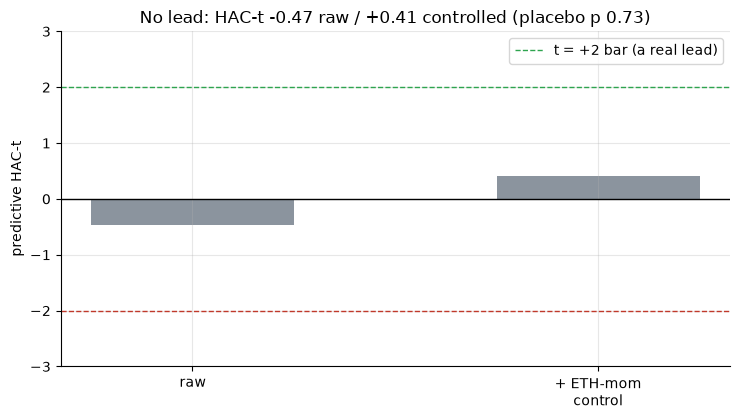

raw HAC-t -0.47 (OLS-t -0.87, R2 0.0005) | controlled +0.41 | placebo p 0.73


In [3]:
mom = st.floor_momentum(DF, LOOKBACK); fwd = st.forward_return(DF, HORIZON)
ethm = st.eth_momentum(DF, LOOKBACK)
raw = st.predictive_regression(mom, fwd)
ctl = st.predictive_regression(mom, fwd, controls=ethm.to_frame())
p = st.placebo_pvalue(mom, fwd, n_perm=500, seed=SEED)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['raw','+ ETH-mom\ncontrol'], [raw['hac_t'], ctl['hac_t']], color=[GREY, GREY], width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1, label='t = +2 bar (a real lead)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('predictive HAC-t'); ax.set_ylim(-3, 3)
ax.set_title(f'No lead: HAC-t {raw["hac_t"]:+.2f} raw / {ctl["hac_t"]:+.2f} controlled (placebo p {p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'raw HAC-t {raw["hac_t"]:+.2f} (OLS-t {raw["ols_t"]:+.2f}, R2 {raw["r2"]:.4f}) | '
      f'controlled {ctl["hac_t"]:+.2f} | placebo p {p:.2f}')

> 💡 In plain words: H₁ **and** H₂ **rejected.** Raw predictive HAC-*t* = **-0.47** (placebo *p* 0.73, R² 0.0005); controlling for ETH's own momentum it is **+0.41**. Floor momentum adds nothing about forward ETH.

### 4c · Robustness — the horizon sweep

The predictive HAC-*t* across five forward horizons, raw and controlled.

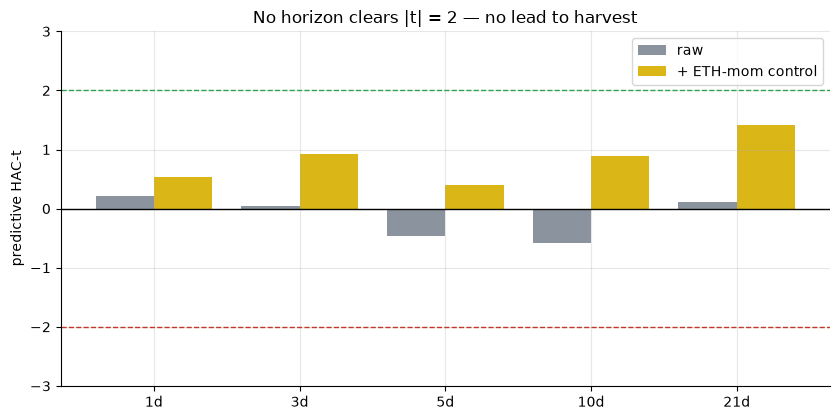

         hac_t_raw  hac_t_ctrl_ethmom
horizon                              
1             0.22               0.54
3             0.04               0.92
5            -0.47               0.41
10           -0.58               0.89
21            0.11               1.42


In [4]:
sweep = st.horizon_sweep(DF, LOOKBACK)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
x = np.arange(len(sweep))
ax.bar(x-0.2, sweep['hac_t_raw'], width=.4, color=GREY, label='raw')
ax.bar(x+0.2, sweep['hac_t_ctrl_ethmom'], width=.4, color=AMBER, label='+ ETH-mom control')
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in sweep.index])
ax.set_ylabel('predictive HAC-t'); ax.set_ylim(-3, 3)
ax.set_title('No horizon clears |t| = 2 — no lead to harvest')
ax.legend(); plt.tight_layout(); plt.show()
print(sweep[['hac_t_raw','hac_t_ctrl_ethmom']].round(2).to_string())

> 💡 In plain words: every horizon's |HAC-*t*| stays under ~1.5 and wanders around zero. There is no forward-predictive edge at 1, 3, 5, 10 or 21 days.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (HAC-*t* -0.47, placebo *p* 0.73); H₂ rejected (+0.41 controlled); no horizon clears |*t*| = 2. Synthetic-only caps it below REAL regardless.
- **Tradability `MIRAGE`** — overlay gross +1.5%/yr → net -3.1%/yr, Sharpe -0.05.
- **NFT floor leads crypto? `BUSTED`** — lagged beta 1.61, lead-lag peak at lag -1: floors follow, not lead.

## 6 · Could you trade it? — the overlay, gross and net

Long ETH when floor momentum > 0, else flat; enter next day; charge 10 bps per position change.

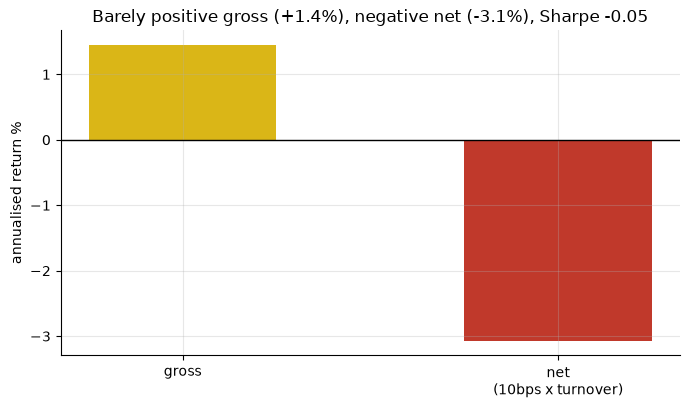

gross +1.4%/yr -> net -3.1%/yr | Sharpe -0.05 | turnover 0.124 | frac long 49%


In [5]:
ov = st.overlay_backtest(DF, lookback=LOOKBACK, cost_bps=10.0, allow_short=False)
fig, ax = plt.subplots(figsize=(7, 4.2))
g, n = ov['gross_ann']*100, ov['net_ann']*100
ax.bar(['gross','net\n(10bps x turnover)'], [g, n], color=[AMBER, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('annualised return %')
ax.set_title(f'Barely positive gross ({g:+.1f}%), negative net ({n:+.1f}%), Sharpe {ov["sharpe_net"]:+.2f}')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr -> net {n:+.1f}%/yr | Sharpe {ov["sharpe_net"]:+.2f} | '
      f'turnover {ov["turnover"]:.3f} | frac long {ov["frac_long"]*100:.0f}%')

> 💡 In plain words: the overlay is just timed *partial* ETH beta (long ~half the days, chosen by a noise signal). Positive gross, **negative net** once you pay to trade. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a genuine lead (`lead_alpha > 0`) of increasing strength — floor momentum now *does* inform future ETH — and watch the predictive HAC-*t* climb past +2, averaged over 25 seeds so no single lucky seed can fake it.

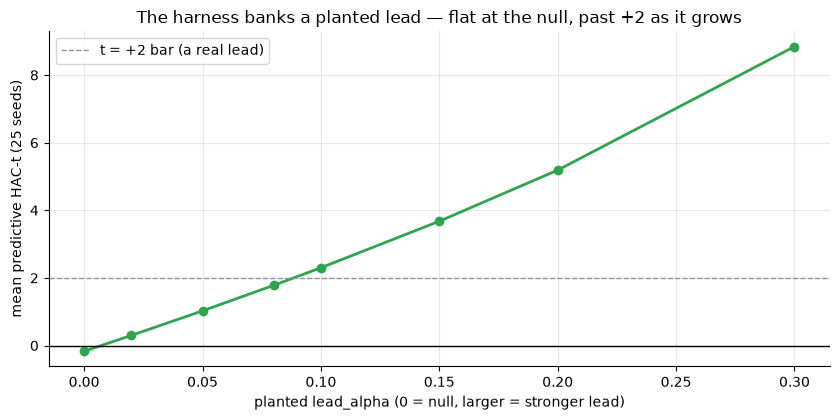

lead_alpha 0.00 -> mean HAC-t -0.17
lead_alpha 0.02 -> mean HAC-t +0.30
lead_alpha 0.05 -> mean HAC-t +1.03
lead_alpha 0.08 -> mean HAC-t +1.78
lead_alpha 0.10 -> mean HAC-t +2.30
lead_alpha 0.15 -> mean HAC-t +3.68
lead_alpha 0.20 -> mean HAC-t +5.19
lead_alpha 0.30 -> mean HAC-t +8.84


In [6]:
alphas = [0.0, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]
ts = [st.synthetic_mean_hac_t(data, lead_alpha=a, horizon=HORIZON, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar (a real lead)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted lead_alpha (0 = null, larger = stronger lead)')
ax.set_ylabel('mean predictive HAC-t (25 seeds)')
ax.set_title('The harness banks a planted lead — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'lead_alpha {a:.2f} -> mean HAC-t {t:+.2f}')

The HAC-*t* is ≈ 0 at the null and rises monotonically past **+2** once a real lead is planted (around `lead_alpha` ≈ 0.10) — so the engine is a faithful detector. The flat real result is therefore a statement about the **economics of an NFT floor index**: it is a lagged high-beta echo of ETH, not a leading risk-appetite signal. And because no clean free NFT floor tape exists, the signal axis is capped below REAL on data availability — the same honesty applied to the desk's [Lego](../../273-lego-returns/), [Whisky](../../275-whisky-cask/) and [Sneaker](../../276-sneaker-resale/) alt-data studies.